## Import packages

In [47]:
# Importing packages
import os
from pathlib import Path

import pandas as pd
import numpy as np

import scanpy as sc
import squidpy as sq
import anndata as ad

import json

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [48]:
# Set working directory
project = Path("/media/nannu1375/Backpack/Shankara/KNC")

os.chdir(project)

## Sample Loading

In [49]:
# Read the h5 files
adata = sc.read_10x_h5(
    filename=project /
    "public_data/Spatial_data/Output-suppli_files/binned_outputs/square_008um/filtered_feature_bc_matrix.h5"
    )

/home/nannu1375/miniconda3/envs/knc_signature/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/nannu1375/miniconda3/envs/knc_signature/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [50]:
# Read the tissue positions file
positions = pd.read_parquet(
    project /
    "public_data/Spatial_data/Output-suppli_files/binned_outputs/square_008um/spatial/tissue_positions.parquet"
)

In [51]:
# Join the positions file with the anndata file
## We are going to merge the positions file with obs first, then take the x y coordinates and put it in obsm since it just needs a matrix of coordinates.
adata.obs = adata.obs.join(
    positions.set_index("barcode")
)

# create the obsm x-y coordinates
adata.obsm["spatial"] = adata.obs[
    ["pxl_col_in_fullres", "pxl_row_in_fullres"]
].to_numpy()

{'spot_diameter_fullres': 29.227274717232252,
 'bin_size_um': 8.0,
 'microns_per_pixel': 0.2737169331522806,
 'tissue_lowres_scalef': 0.010981168,
 'fiducial_diameter_fullres': 1205.6250820858302,
 'tissue_hires_scalef': 0.10981167,
 'regist_target_img_scalef': 0.10981167}

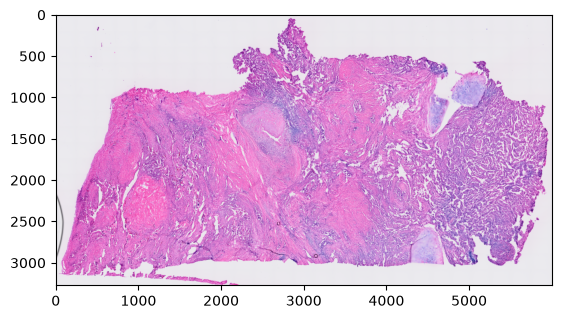

In [52]:
# read the scale factors
with open(
    project /
    "public_data/Spatial_data/Output-suppli_files/binned_outputs/square_008um/spatial/scalefactors_json.json"
) as f:
    scalefactors = json.load(f)

# Read the h&e images
hires = mpimg.imread(
    project /
    "public_data/Spatial_data/Output-suppli_files/binned_outputs/square_008um/spatial/tissue_hires_image.png"
)

lowres = mpimg.imread(
    project /
    "public_data/Spatial_data/Output-suppli_files/binned_outputs/square_008um/spatial/tissue_lowres_image.png"
)

# Display the image
plt.imshow(hires)
scalefactors

In [53]:
# Build the uns dictionary
adata.uns["spatial"] = {
    "Visium_HD": {
        "images":{
            "hires": hires,
            "lowres": lowres,
        },
        "scalefactors": scalefactors,
        "metadata": {}
    }
}

## Sanity checks

In [54]:
# =============================================================================
# Sanity checks for the Spatial AnnData object
# =============================================================================

print("=" * 70)
print("AnnData Summary")
print("=" * 70)
print(adata)

print("\n")

# =============================================================================
# Check dimensions
# =============================================================================

print("=" * 70)
print("Dimensions")
print("=" * 70)

print(f"Number of spatial bins (obs): {adata.n_obs:,}")
print(f"Number of genes (var):        {adata.n_vars:,}")

print("\n")

# =============================================================================
# Check available AnnData slots
# =============================================================================

print("=" * 70)
print("Available Slots")
print("=" * 70)

print("obsm keys :", list(adata.obsm.keys()))
print("uns keys  :", list(adata.uns.keys()))

print("\n")

# =============================================================================
# Check observation (spot/bin) metadata
# =============================================================================

print("=" * 70)
print("Observation metadata (adata.obs)")
print("=" * 70)

display(adata.obs.head())

print(f"\nShape : {adata.obs.shape}")

print("\n")

# =============================================================================
# Check gene metadata
# =============================================================================

print("=" * 70)
print("Gene metadata (adata.var)")
print("=" * 70)

display(adata.var.head())

print(f"\nShape : {adata.var.shape}")

print("\n")

# =============================================================================
# Check expression matrix
# =============================================================================

print("=" * 70)
print("Expression Matrix (adata.X)")
print("=" * 70)

print(type(adata.X))
print("Shape :", adata.X.shape)

print("\n")

# =============================================================================
# Check spatial coordinates
# =============================================================================

print("=" * 70)
print("Spatial Coordinates")
print("=" * 70)

print(type(adata.obsm["spatial"]))
print("Shape :", adata.obsm["spatial"].shape)

print("\nFirst five coordinates:")
print(adata.obsm["spatial"][:5])

print("\n")

# =============================================================================
# Check spatial metadata
# =============================================================================

print("=" * 70)
print("Spatial Metadata")
print("=" * 70)

library_id = list(adata.uns["spatial"].keys())[0]

print("Library ID :", library_id)

print("\nAvailable entries:")
print(list(adata.uns["spatial"][library_id].keys()))

print("\nScale factors:")
print(adata.uns["spatial"][library_id]["scalefactors"])

print("\n")

# =============================================================================
# Verify consistency
# =============================================================================

print("=" * 70)
print("Consistency Checks")
print("=" * 70)

assert adata.n_obs == adata.obs.shape[0], "Mismatch: obs rows"

assert adata.n_obs == adata.obsm["spatial"].shape[0], \
    "Mismatch: spatial coordinates"

assert adata.n_vars == adata.var.shape[0], \
    "Mismatch: gene metadata"

print("✓ Number of observations matches obs")
print("✓ Number of observations matches spatial coordinates")
print("✓ Number of genes matches var")

print("\nAll sanity checks passed!")

AnnData Summary
AnnData object with n_obs × n_vars = 617107 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


Dimensions
Number of spatial bins (obs): 617,107
Number of genes (var):        18,085


Available Slots
obsm keys : ['spatial']
uns keys  : ['spatial']


Observation metadata (adata.obs)


,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
s_008um_00269_00526-1,1,269,526,16236.548254,33352.778091
s_008um_00260_00253-1,1,260,253,16458.785485,25372.997425
s_008um_00433_00599-1,1,433,599,11455.322346,35511.071047
s_008um_00266_00304-1,1,266,304,16291.069973,26864.388225
s_008um_00154_00449-1,1,154,449,19585.650391,31084.869628



Shape : (617107, 5)


Gene metadata (adata.var)


,gene_ids,feature_types,genome
SAMD11,ENSG00000187634,Gene Expression,GRCh38
NOC2L,ENSG00000188976,Gene Expression,GRCh38
KLHL17,ENSG00000187961,Gene Expression,GRCh38
PLEKHN1,ENSG00000187583,Gene Expression,GRCh38
PERM1,ENSG00000187642,Gene Expression,GRCh38



Shape : (18085, 3)


Expression Matrix (adata.X)
<class 'scipy.sparse._csr.csr_matrix'>
Shape : (617107, 18085)


Spatial Coordinates
<class 'numpy.ndarray'>
Shape : (617107, 2)

First five coordinates:
[[33352.77809119 16236.54825447]
 [25372.99742484 16458.78548475]
 [35511.07104702 11455.32234612]
 [26864.38822477 16291.06997278]
 [31084.86962755 19585.65039099]]


Spatial Metadata
Library ID : Visium_HD

Available entries:
['images', 'scalefactors', 'metadata']

Scale factors:
{'spot_diameter_fullres': 29.227274717232252, 'bin_size_um': 8.0, 'microns_per_pixel': 0.2737169331522806, 'tissue_lowres_scalef': 0.010981168, 'fiducial_diameter_fullres': 1205.6250820858302, 'tissue_hires_scalef': 0.10981167, 'regist_target_img_scalef': 0.10981167}


Consistency Checks
✓ Number of observations matches obs
✓ Number of observations matches spatial coordinates
✓ Number of genes matches var

All sanity checks passed!


In [55]:
# Create a copy of the raw counts
adata.layers["counts"] = adata.X.copy()

print(adata.layers["counts"])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 122041881 stored elements and shape (617107, 18085)>
  Coords	Values
  (0, 267)	1.0
  (0, 427)	1.0
  (0, 786)	1.0
  (0, 1218)	2.0
  (0, 1410)	1.0
  (0, 2103)	1.0
  (0, 2166)	1.0
  (0, 2289)	1.0
  (0, 2698)	3.0
  (0, 2831)	1.0
  (0, 3099)	1.0
  (0, 3575)	1.0
  (0, 4865)	1.0
  (0, 5045)	1.0
  (0, 5359)	2.0
  (0, 5377)	2.0
  (0, 5455)	1.0
  (0, 5995)	1.0
  (0, 6697)	1.0
  (0, 6709)	1.0
  (0, 6719)	1.0
  (0, 6883)	4.0
  (0, 6920)	1.0
  (0, 7027)	1.0
  (0, 8170)	1.0
  :	:
  (617105, 17076)	1.0
  (617105, 17165)	1.0
  (617105, 17190)	1.0
  (617105, 17192)	1.0
  (617105, 17236)	1.0
  (617105, 17282)	1.0
  (617105, 17349)	1.0
  (617105, 17427)	1.0
  (617105, 17440)	1.0
  (617105, 17591)	1.0
  (617105, 17630)	1.0
  (617105, 17836)	1.0
  (617105, 17885)	1.0
  (617105, 17907)	1.0
  (617105, 18074)	1.0
  (617105, 18076)	4.0
  (617105, 18077)	1.0
  (617105, 18078)	1.0
  (617105, 18079)	1.0
  (617105, 18080)	1.0
  (617105, 18081)	3.0
  (6

## QC step

In [56]:
# Annotate mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Display the mitochondrial genes and how many
print("Number of mitochondrial and nuclear genes (False is nuclear and true is mitochondrial): ", adata.var["mt"].value_counts())
print("List of gene names of the mitochondrial genes:\n", adata.var_names[adata.var["mt"] == True])

Number of mitochondrial and nuclear genes (False is nuclear and true is mitochondrial):  mt
False    18074
True        11
Name: count, dtype: int64
List of gene names of the mitochondrial genes:
 Index(['MT-ND1', 'MT-ND2', 'MT-CO2', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L',
       'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object')


In [57]:
# Calculating QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

In [58]:
print(adata.obs.columns)
print(adata.obs.head())

Index(['in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres',
       'pxl_col_in_fullres', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt'],
      dtype='object')
                       in_tissue  array_row  array_col  pxl_row_in_fullres  \
s_008um_00269_00526-1          1        269        526        16236.548254   
s_008um_00260_00253-1          1        260        253        16458.785485   
s_008um_00433_00599-1          1        433        599        11455.322346   
s_008um_00266_00304-1          1        266        304        16291.069973   
s_008um_00154_00449-1          1        154        449        19585.650391   

                       pxl_col_in_fullres  n_genes_by_counts  \
s_008um_00269_00526-1        33352.778091        

In [59]:
# Get summary of qc metrics
print(adata.obs[
    ["total_counts",
    "n_genes_by_counts",
    "pct_counts_mt"]
].describe())

print(adata.obs[
    ["total_counts",
     "n_genes_by_counts",
     "pct_counts_mt"]
].quantile(
    [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
))

        total_counts  n_genes_by_counts  pct_counts_mt
count  617107.000000      617107.000000  616510.000000
mean      268.007355         197.764538       1.149681
std       231.783890         162.666550       1.606822
min         0.000000           0.000000       0.000000
25%       101.000000          80.000000       0.000000
50%       203.000000         153.000000       0.881057
75%       373.000000         275.000000       1.559792
max      4751.000000        2630.000000     100.000000
      total_counts  n_genes_by_counts  pct_counts_mt
0.01           4.0                3.0       0.000000
0.05          22.0               21.0       0.000000
0.25         101.0               80.0       0.000000
0.50         203.0              153.0       0.881057
0.75         373.0              275.0       1.559792
0.95         723.0              515.0       3.361345
0.99        1047.0              738.0       6.000000


In [60]:
# Rename duplicate genes
dedup = adata.var_names_make_unique()
if dedup == True:
    print("Duplicate gene names removed!")

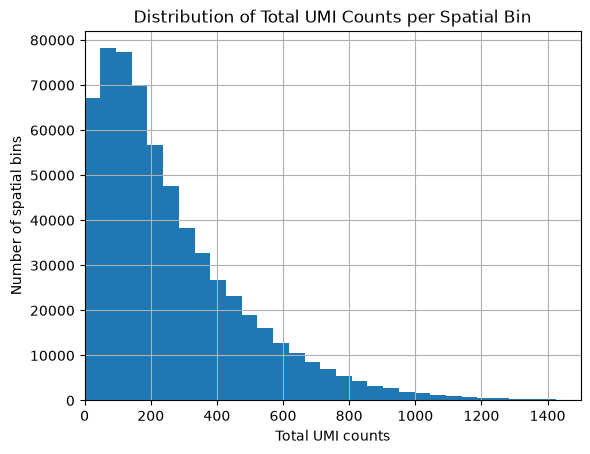

In [61]:
# Plot the qc metrics summary
adata.obs["total_counts"].hist(bins=100)
plt.xlim(0, 1500)
plt.title("Distribution of Total UMI Counts per Spatial Bin")
plt.xlabel("Total UMI counts")
plt.ylabel("Number of spatial bins")

plt.savefig(
    "Plots/Spatial/QC/umi_counts_hist.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


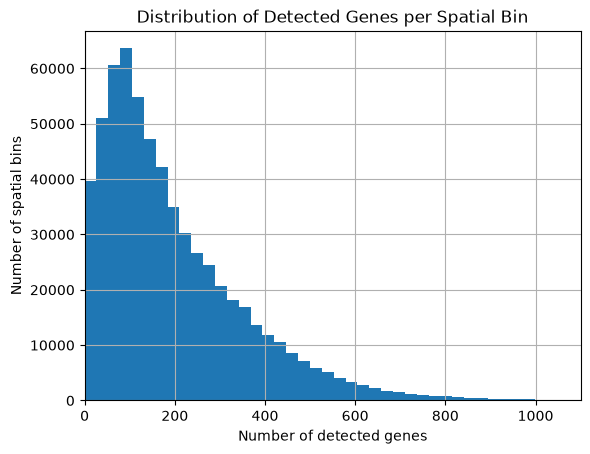

In [62]:
adata.obs["n_genes_by_counts"].hist(bins=100)
plt.xlim(0, 1100)
plt.title("Distribution of Detected Genes per Spatial Bin")
plt.xlabel("Number of detected genes")
plt.ylabel("Number of spatial bins")

plt.savefig(
    "Plots/Spatial/QC/genes_counts_hist.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

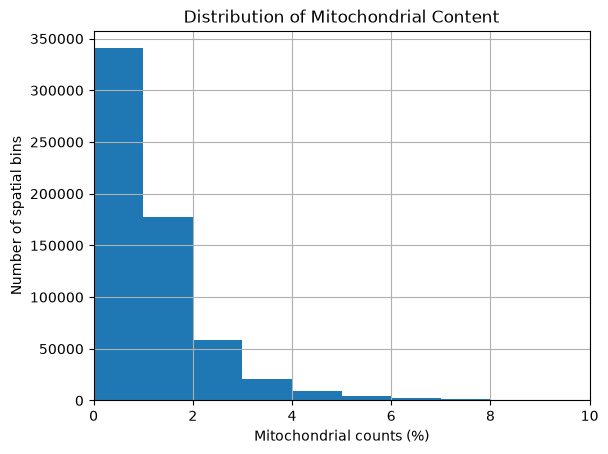

In [63]:
adata.obs["pct_counts_mt"].hist(bins=100)
plt.xlim(0, 10)
plt.title("Distribution of Mitochondrial Content")
plt.xlabel("Mitochondrial counts (%)")
plt.ylabel("Number of spatial bins")

plt.savefig(
    "Plots/Spatial/QC/mtGenes_counts_hist.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

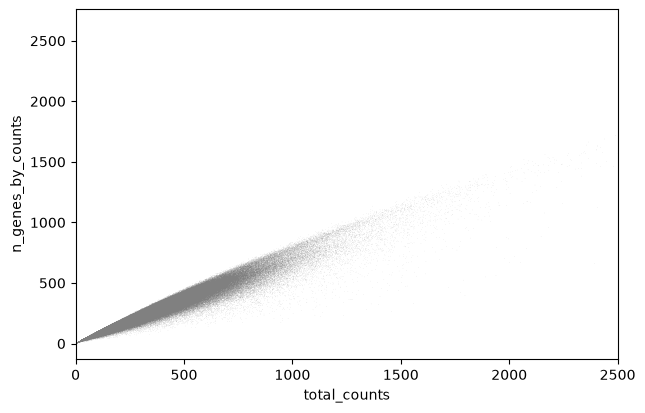

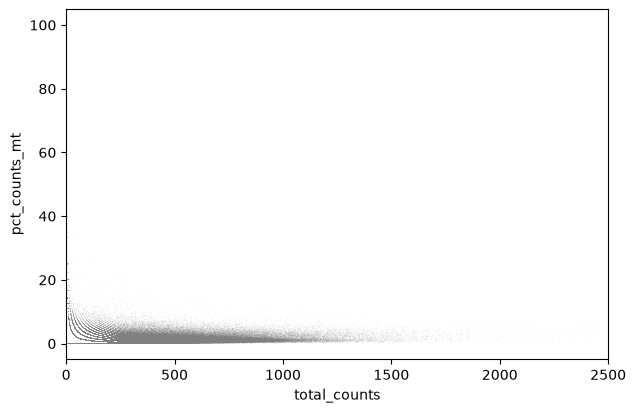

In [64]:
# UMI vs gene count scatter plot
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    show=False 
)

plt.xlim(0, 2500)

plt.savefig(
    "Plots/Spatial/QC/umiVSgene.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

# mt vs gene count scatter plot
sc.pl.scatter(
    adata,
    x="total_counts",
    y="pct_counts_mt",
    show=False 
)

plt.xlim(0, 2500)

plt.savefig(
    "Plots/Spatial/QC/mtVSgene.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [65]:
# Check how many genes would be lost if filtered 
for cutoff in [5, 10, 20, 30, 50, 75, 100]:
    removed = (adata.obs["n_genes_by_counts"] < cutoff).sum()
    pct = removed / adata.n_obs * 100
    print(f"< {cutoff:3} genes : {removed:7,d} bins ({pct:.2f}%)")

# Check how many bins would be lost if filtered 
for cutoff in [5, 10, 20, 30, 50, 75, 100]:
    removed = (adata.obs["total_counts"] < cutoff).sum()
    pct = removed / adata.n_obs * 100
    print(f"< {cutoff:3} UMIs : {removed:7,d} bins ({pct:.2f}%)")

<   5 genes :   8,489 bins (1.38%)
<  10 genes :  17,070 bins (2.77%)
<  20 genes :  29,242 bins (4.74%)
<  30 genes :  44,640 bins (7.23%)
<  50 genes :  84,239 bins (13.65%)
<  75 genes : 141,467 bins (22.92%)
< 100 genes : 201,080 bins (32.58%)
<   5 UMIs :   8,302 bins (1.35%)
<  10 UMIs :  16,693 bins (2.71%)
<  20 UMIs :  27,739 bins (4.50%)
<  30 UMIs :  40,032 bins (6.49%)
<  50 UMIs :  70,266 bins (11.39%)
<  75 UMIs : 110,274 bins (17.87%)
< 100 UMIs : 151,854 bins (24.61%)


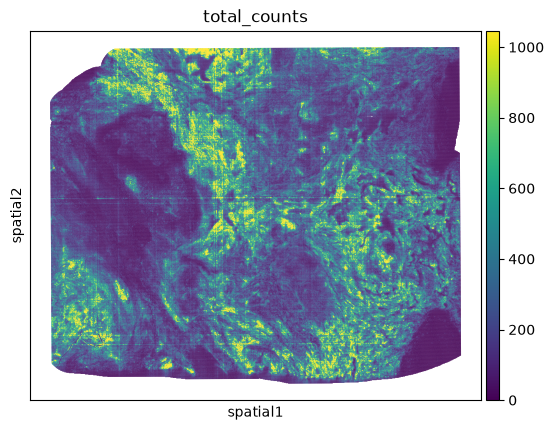

In [66]:
# Plot the gene count on tissue image
ax = sc.pl.embedding(
    adata,
    basis="spatial",
    color="total_counts",
    size=1,
    vmax="p99",
    show=False
)

fig = ax.figure

fig.savefig(
    "Plots/Spatial/QC/spatial_gene_counts.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

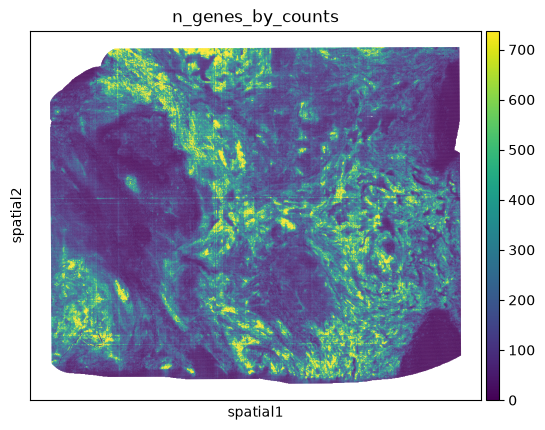

In [67]:
# Plot the umi count on tissue image
ax = sc.pl.embedding(
    adata,
    basis="spatial",
    color="n_genes_by_counts",
    size=1,
    vmax="p99",
    show=False 
)

fig = ax.figure

fig.savefig(
    "Plots/Spatial/QC/spatial_umi_counts.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


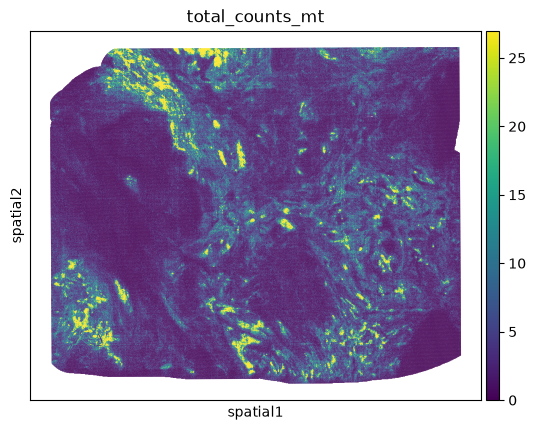

In [68]:
# Plot the mt count on tissue image
sc.pl.embedding(
    adata,
    basis="spatial",
    color="total_counts_mt",
    size=1,
    vmax="p99",
    show=False
)

fig = ax.figure

fig.savefig(
    "Plots/Spatial/QC/spatial_umi_counts.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()